**Task 1:** Data Cleaning & Preprocessing
**Internship:** Synent Technologies – Data Science Internship

**Dataset:** Titanic Dataset

**Objective:** Clean and prepare raw data for analysis

**By:** Sneha Agarwal

## Step 1: Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Dataset

In [20]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Initial Exploration

In [21]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])

          Missing Count  Missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467


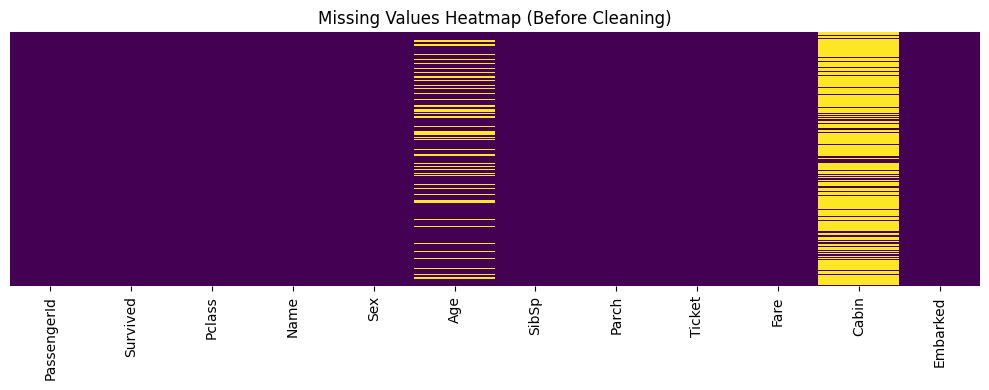

In [22]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Before Cleaning)')
plt.tight_layout()
plt.show()

## Step 4: Handle Missing Values

In [23]:
# Age → filling with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked → filling with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin → drop (77% missing)
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_754/1300320667.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_754/1300320667.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

## Step 5: Remove Duplicates

In [24]:
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after: {df.duplicated().sum()}")
print(f"Shape after: {df.shape}")

Duplicates before: 0
Duplicates after: 0
Shape after: (891, 11)


## Step 6: Convert Data Types

In [25]:
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object


## Step 7: Rename Columns

In [26]:
df.rename(columns={
    'PassengerId': 'Passenger_ID',
    'Pclass'     : 'Passenger_Class',
    'SibSp'      : 'Siblings_Spouses',
    'Parch'      : 'Parents_Children',
    'Embarked'   : 'Port_of_Embarkation'
}, inplace=True)

print("Renamed Columns:")
print(df.columns.tolist())

Renamed Columns:
['Passenger_ID', 'Survived', 'Passenger_Class', 'Name', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Ticket', 'Fare', 'Port_of_Embarkation']


In [27]:
print("=== FINAL DATASET ===")
print(f"Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
df.head()

=== FINAL DATASET ===
Shape: (891, 11)

Missing Values:
Passenger_ID           0
Survived               0
Passenger_Class        0
Name                   0
Sex                    0
Age                    0
Siblings_Spouses       0
Parents_Children       0
Ticket                 0
Fare                   0
Port_of_Embarkation    0
dtype: int64


,Passenger_ID,Survived,Passenger_Class,Name,Sex,Age,Siblings_Spouses,Parents_Children,Ticket,Fare,Port_of_Embarkation
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## Step 9: Final Cleaned Dataset

In [29]:
df.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved as titanic_cleaned.csv ✅")

Cleaned dataset saved as titanic_cleaned.csv ✅
